In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error

In [214]:
# 폰트 설정
import matplotlib as mpl
import matplotlib.font_manager as fm

font_path = r"C:\Windows\Fonts\malgun.ttf"  
font_prop = fm.FontProperties(fname=font_path)
mpl.rcParams['font.family'] = font_prop.get_name()
mpl.rcParams['axes.unicode_minus'] = False

In [215]:
df = pd.read_excel('./datasets/swatch.xlsx')
df

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con)
0,ACF25-01,105.20,1150,320,280
1,ACF25-02,99.30,1450,470,220
2,ACF25-03,119.70,1150,1150,550
3,ACF25-04,110.40,1300,850,850
4,ACF25-05,103.44,1016,470,580
5,ACF25-06,122.83,1080,20,140
6,ACF25-07,154.49,1139,380,10
7,ACF25-08,140.00,1300,20,5
8,ACF25-09,130.00,2197,50,5


In [216]:
# info
print('shape:', df.shape)
print()
print(df.info())

shape: (9, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sample               9 non-null      object 
 1   평량(g/m2)             9 non-null      float64
 2   BET(m2/g)            9 non-null      int64  
 3   SWATCH(GD) 24h(Con)  9 non-null      int64  
 4   SWATCH(HD) 24h(Con)  9 non-null      int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 492.0+ bytes
None


In [217]:
# Descriptive Statistics
desc_stats = df.drop(columns='Sample').copy()
desc_stats = df.describe().T
desc_stats['CV(%)'] = (desc_stats['std'] / desc_stats['mean'] * 100)

print('기술 통계')
display(desc_stats.round(2))

print()
print('미군 방호성능 기준 합/불 여부')
GD_base = 357
HD_base = 671

df['GD_PASS'] = df['SWATCH(GD) 24h(Con)'] <= GD_base
df['HD_PASS'] = df['SWATCH(HD) 24h(Con)'] <= HD_base
df['All_PASS'] = (df['SWATCH(GD) 24h(Con)'] <= GD_base) & (df['SWATCH(HD) 24h(Con)'] <= HD_base)

summary = df.copy()
summary['GD_PASS'] = summary['GD_PASS'].map({True: '합격', False: '불합격'})
summary['HD_PASS'] = summary['HD_PASS'].map({True: '합격', False: '불합격'})
summary['All_PASS'] = summary['All_PASS'].map({True: '합격', False: '불합격'})
display(summary)

print('HD 합격 샘플:', summary.loc[summary['GD_PASS'] == '합격', 'Sample'].tolist())
print('GD 합격 샘플:', summary.loc[summary['HD_PASS'] == '합격', 'Sample'].tolist())
print('모두 합격 샘플:', summary.loc[summary['All_PASS'] == '합격', 'Sample'].tolist())



기술 통계


,count,mean,std,min,25%,50%,75%,max,CV(%)
평량(g/m2),9.0,120.60,18.40,99.3,105.2,119.7,130.0,154.49,15.26
BET(m2/g),9.0,1309.11,358.18,1016.0,1139.0,1150.0,1300.0,2197.00,27.36
SWATCH(GD) 24h(Con),9.0,414.44,385.85,20.0,50.0,380.0,470.0,1150.00,93.10
SWATCH(HD) 24h(Con),9.0,293.33,302.81,5.0,10.0,220.0,550.0,850.00,103.23



미군 방호성능 기준 합/불 여부


,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con),GD_PASS,HD_PASS,All_PASS
0,ACF25-01,105.20,1150,320,280,합격,합격,합격
1,ACF25-02,99.30,1450,470,220,불합격,합격,불합격
2,ACF25-03,119.70,1150,1150,550,불합격,합격,불합격
3,ACF25-04,110.40,1300,850,850,불합격,불합격,불합격
4,ACF25-05,103.44,1016,470,580,불합격,합격,불합격
5,ACF25-06,122.83,1080,20,140,합격,합격,합격
6,ACF25-07,154.49,1139,380,10,불합격,합격,불합격
7,ACF25-08,140.00,1300,20,5,합격,합격,합격
8,ACF25-09,130.00,2197,50,5,합격,합격,합격


HD 합격 샘플: ['ACF25-01', 'ACF25-06', 'ACF25-08', 'ACF25-09']
GD 합격 샘플: ['ACF25-01', 'ACF25-02', 'ACF25-03', 'ACF25-05', 'ACF25-06', 'ACF25-07', 'ACF25-08', 'ACF25-09']
모두 합격 샘플: ['ACF25-01', 'ACF25-06', 'ACF25-08', 'ACF25-09']


# 변수 분포 시각화

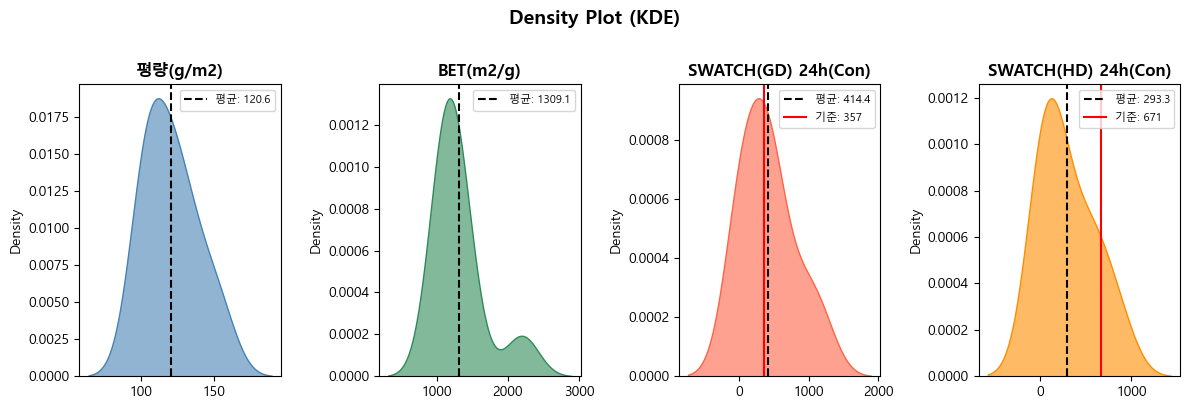

In [218]:
figs, axes = plt.subplots(1,4, figsize=(12,4))
cols = df.columns[1:5].tolist()
limits = [None, None, GD_base, HD_base]
colors = ['steelblue', 'seagreen', 'tomato', 'darkorange']

# 히스토그램
for i, (col, lim, color) in enumerate(zip(cols, limits, colors)):
    ax_density = axes[i]
    
    temp = pd.to_numeric(df[col]).dropna()

    # KDE plot (density)
    sns.kdeplot(temp, ax=ax_density, fill=True, color=color, alpha=0.6)

    ax_density.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'평균: {df[col].mean():.1f}')

    if lim:
        ax_density.axvline(lim, color='red', linestyle='-', linewidth=1.5, label=f'기준: {lim}')
    ax_density.set_title(col, fontsize=12, fontweight='bold')
    ax_density.set_xlabel('')
    ax_density.legend(fontsize=8)

plt.suptitle('Density Plot (KDE)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

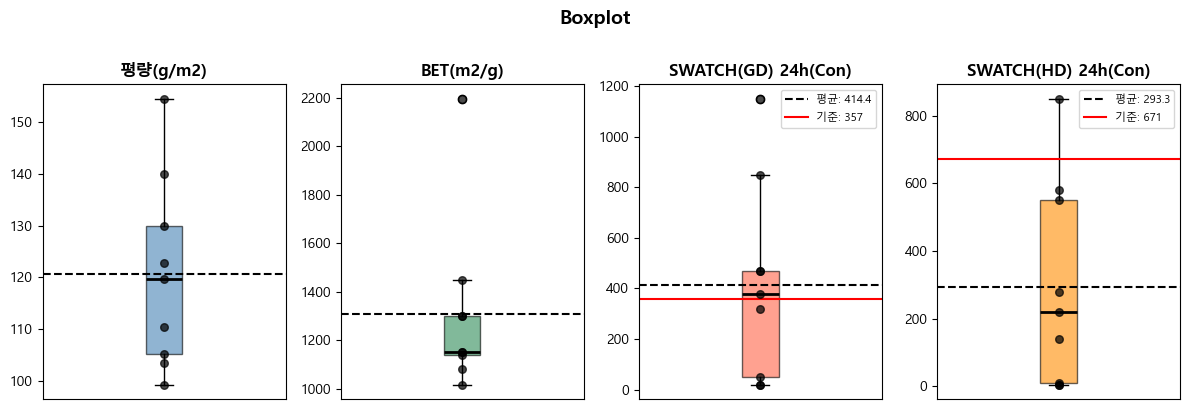

In [219]:
figs, axes = plt.subplots(1,4, figsize=(12,4))
cols = df.columns[1:5].tolist()
limits = [None, None, GD_base, HD_base]
colors = ['steelblue', 'seagreen', 'tomato', 'darkorange']

# 히스토그램
for i, (col, lim, color) in enumerate(zip(cols, limits, colors)):
    ax_box = axes[i]
    
    # Boxplot
    bp = ax_box.boxplot(df[col], patch_artist=True,
                        boxprops=dict(facecolor=color, alpha=0.6),
                        medianprops=dict(color='black', linewidth=2))
    ax_box.axhline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'평균: {df[col].mean():.1f}')

    if lim:
        ax_box.axhline(lim, color='red', linestyle='-', linewidth=1.5, label=f'기준: {lim}')
        ax_box.legend(fontsize=8)

    ax_box.scatter([1]*len(df), df[col], color='black', zorder=5, s=30, alpha=0.7)
    ax_box.set_title(col, fontsize=12, fontweight='bold')
    ax_box.set_xticks([])

plt.suptitle('Boxplot', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# (샘플별) 미군 방호성능 24시간 기준 합/불 여부

Axes(0.125,0.11;0.352273x0.77) SWATCH(GD) 24h(Con) 357 tomato GD 방호성능 (<= 357)
['steelblue', 'tomato', 'tomato', 'tomato', 'tomato', 'steelblue', 'tomato', 'steelblue', 'steelblue']
Axes(0.547727,0.11;0.352273x0.77) SWATCH(HD) 24h(Con) 671 darkorange HD 방호성능 (<= 671)
['steelblue', 'steelblue', 'steelblue', 'darkorange', 'steelblue', 'steelblue', 'steelblue', 'steelblue', 'steelblue']


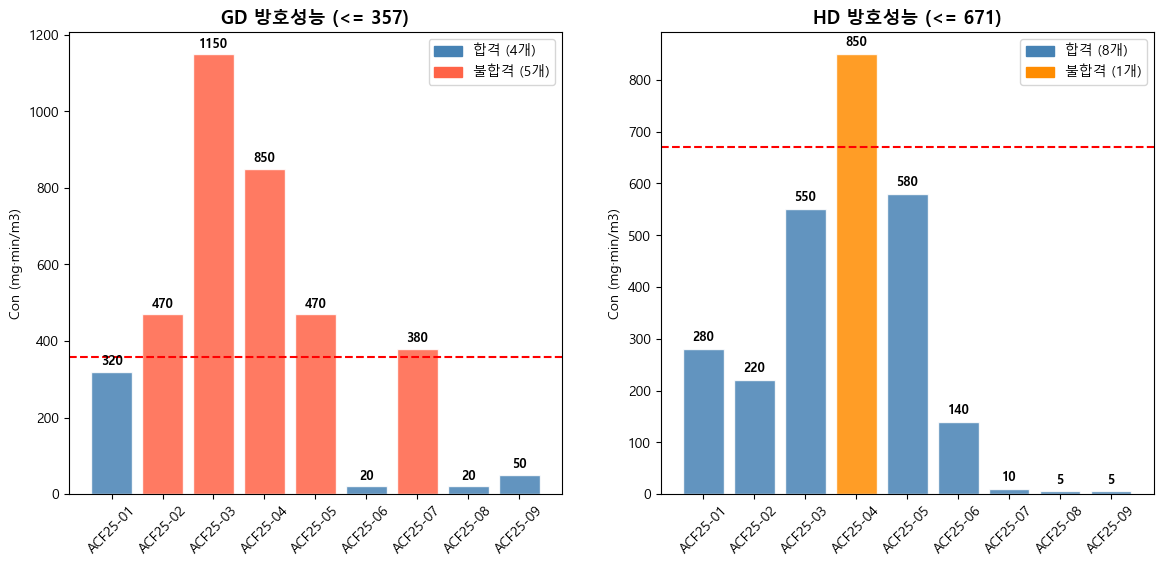

In [220]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
for ax, (y_col, lim, color, title) in zip(axes, [
    ('SWATCH(GD) 24h(Con)', GD_base, 'tomato',    'GD 방호성능 (<= 357)'),
    ('SWATCH(HD) 24h(Con)', HD_base, 'darkorange','HD 방호성능 (<= 671)')]):
    print(ax, y_col, lim, color, title)

    pass_mask = df[y_col] <= lim
    bar_colors = [color if not p else 'steelblue' for p in pass_mask]
    print(bar_colors)

    bars = ax.bar(df['Sample'], df[y_col], color=bar_colors, edgecolor='white', alpha=0.85)
    ax.axhline(lim, color='red', linestyle='--', linewidth=1.5, label=f'기준={lim}')

    for bar, val in zip(bars, df[y_col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+10,
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    # ax.set_xlabel('Sample')
    ax.set_ylabel('Con (mg·min/m3)')
    ax.tick_params(axis='x', rotation=45)

    pass_patch = mpatches.Patch(color='steelblue', label=f'합격 ({pass_mask.sum()}개)')
    fail_patch = mpatches.Patch(color=color, label=f'불합격 ({(~pass_mask).sum()}개)')
    ax.legend(handles=[pass_patch, fail_patch])

# (변수별) 미군 방호성능 24시간 기준 합/불 여부

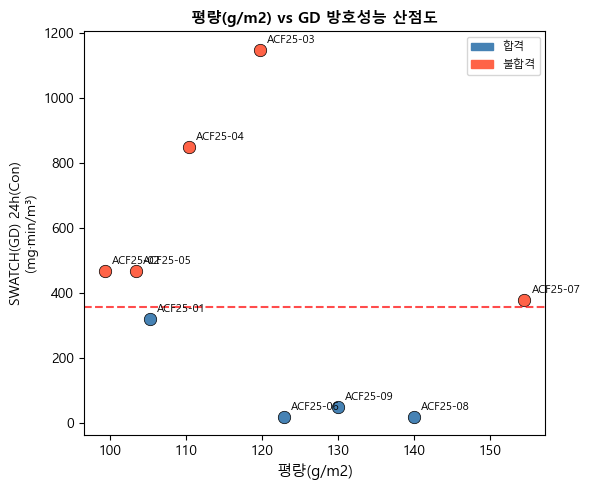

In [291]:
fig, axes = plt.subplots(1, 1, figsize=(6,5))

pairs = [
    ('평량(g/m2)', 'SWATCH(GD) 24h(Con)', 'GD 방호성능', 'steelblue', GD_base),
    # ('평량(g/m2)', 'SWATCH(HD) 24h(Con)', 'HD 방호성능', 'darkorange', HD_base),
    # ('BET(m2/g)',  'SWATCH(GD) 24h(Con)', 'GD 방호성능', 'seagreen',  GD_base),
    # ('BET(m2/g)',  'SWATCH(HD) 24h(Con)', 'HD 방호성능', 'mediumpurple', HD_base),
]

for ax, (x_col, y_col, y_label, color, lim) in zip([axes], pairs):
    x = df[x_col]
    y = df[y_col]

    slope, intercept, r, p, se = stats.linregress(x, y)

    # x_line = np.linspace(x.min(), x.max(), 100)
    # y_line = slope * x_line + intercept
    # ax.plot(x_line, y_line, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)

    for _, row in df.iterrows():
        c = 'steelblue' if row[y_col] <= lim else 'tomato'
        ax.scatter(row[x_col], row[y_col], color=c, s=80, edgecolors='black', linewidths=0.5)
        ax.annotate(row['Sample'], (row[x_col], row[y_col]),
            textcoords='offset points', xytext=(5, 5), fontsize=8)

    # 기준선
    ax.axhline(lim, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'기준={lim}')

    # 레이블
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel(y_col + f'\n(mg·min/m³)', fontsize=10)
    ax.set_title(f'{x_col} vs {y_label} 산점도', fontsize=11, fontweight='bold')

    pass_p = mpatches.Patch(color='steelblue', label='합격')
    fail_p = mpatches.Patch(color='tomato', label='불합격')
    ax.legend(handles=[pass_p, fail_p], fontsize=8, loc='upper right')

# plt.suptitle('X 변수 vs Y 변수 산점도', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

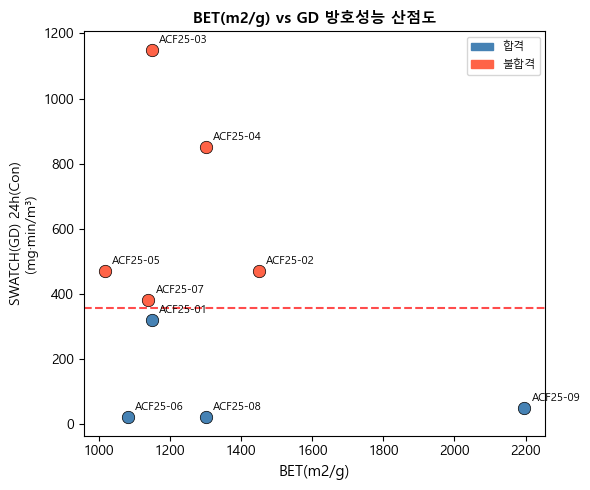

In [292]:
fig, axes = plt.subplots(1, 1, figsize=(6,5))

pairs = [
    # ('평량(g/m2)', 'SWATCH(GD) 24h(Con)', 'GD 방호성능', 'steelblue', GD_base),
    # ('평량(g/m2)', 'SWATCH(HD) 24h(Con)', 'HD 방호성능', 'darkorange', HD_base),
    ('BET(m2/g)',  'SWATCH(GD) 24h(Con)', 'GD 방호성능', 'seagreen',  GD_base),
    # ('BET(m2/g)',  'SWATCH(HD) 24h(Con)', 'HD 방호성능', 'mediumpurple', HD_base),
]

for ax, (x_col, y_col, y_label, color, lim) in zip([axes], pairs):
    x = df[x_col]
    y = df[y_col]

    slope, intercept, r, p, se = stats.linregress(x, y)

    # x_line = np.linspace(x.min(), x.max(), 100)
    # y_line = slope * x_line + intercept
    # ax.plot(x_line, y_line, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)

    for _, row in df.iterrows():
        c = 'steelblue' if row[y_col] <= lim else 'tomato'
        ax.scatter(row[x_col], row[y_col], color=c, s=80, edgecolors='black', linewidths=0.5)
        ax.annotate(row['Sample'], (row[x_col], row[y_col]),
            textcoords='offset points', xytext=(5, 5), fontsize=8)

    # 기준선
    ax.axhline(lim, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'기준={lim}')

    # 레이블
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel(y_col + f'\n(mg·min/m³)', fontsize=10)
    ax.set_title(f'{x_col} vs {y_label} 산점도', fontsize=11, fontweight='bold')

    pass_p = mpatches.Patch(color='steelblue', label='합격')
    fail_p = mpatches.Patch(color='tomato', label='불합격')
    ax.legend(handles=[pass_p, fail_p], fontsize=8, loc='upper right')

# plt.suptitle('X 변수 vs Y 변수 산점도', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

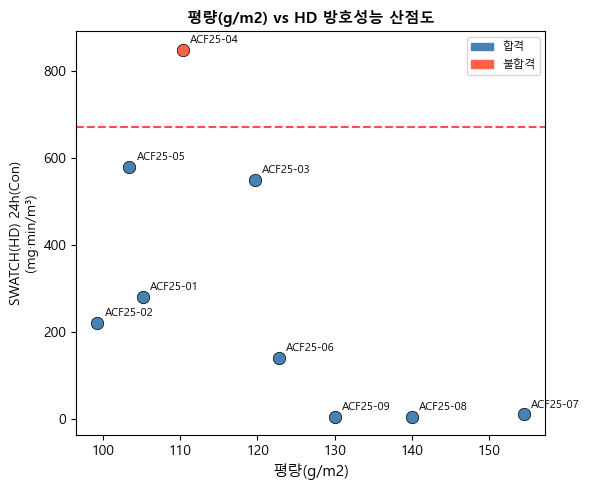

In [293]:
fig, axes = plt.subplots(1, 1, figsize=(6,5))

pairs = [
    # ('평량(g/m2)', 'SWATCH(GD) 24h(Con)', 'GD 방호성능', 'steelblue', GD_base),
    ('평량(g/m2)', 'SWATCH(HD) 24h(Con)', 'HD 방호성능', 'darkorange', HD_base),
    # ('BET(m2/g)',  'SWATCH(GD) 24h(Con)', 'GD 방호성능', 'seagreen',  GD_base),
    # ('BET(m2/g)',  'SWATCH(HD) 24h(Con)', 'HD 방호성능', 'mediumpurple', HD_base),
]

for ax, (x_col, y_col, y_label, color, lim) in zip([axes], pairs):
    x = df[x_col]
    y = df[y_col]

    slope, intercept, r, p, se = stats.linregress(x, y)

    # x_line = np.linspace(x.min(), x.max(), 100)
    # y_line = slope * x_line + intercept
    # ax.plot(x_line, y_line, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)

    for _, row in df.iterrows():
        c = 'steelblue' if row[y_col] <= lim else 'tomato'
        ax.scatter(row[x_col], row[y_col], color=c, s=80, edgecolors='black', linewidths=0.5)
        ax.annotate(row['Sample'], (row[x_col], row[y_col]),
            textcoords='offset points', xytext=(5, 5), fontsize=8)

    # 기준선
    ax.axhline(lim, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'기준={lim}')

    # 레이블
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel(y_col + f'\n(mg·min/m³)', fontsize=10)
    ax.set_title(f'{x_col} vs {y_label} 산점도', fontsize=11, fontweight='bold')

    pass_p = mpatches.Patch(color='steelblue', label='합격')
    fail_p = mpatches.Patch(color='tomato', label='불합격')
    ax.legend(handles=[pass_p, fail_p], fontsize=8, loc='upper right')

# plt.suptitle('X 변수 vs Y 변수 산점도', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

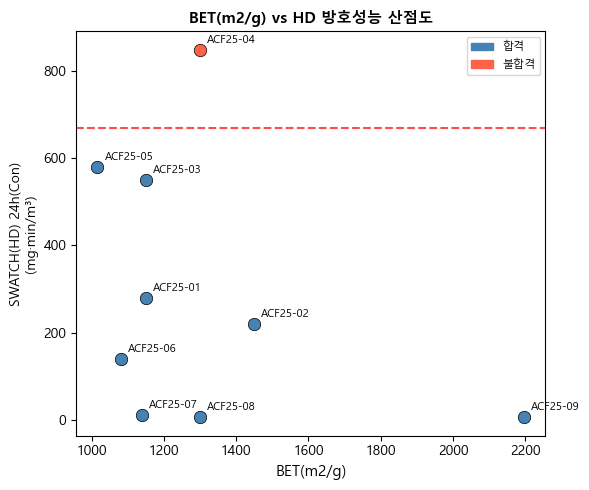

In [294]:
fig, axes = plt.subplots(1, 1, figsize=(6,5))

pairs = [
    # ('평량(g/m2)', 'SWATCH(GD) 24h(Con)', 'GD 방호성능', 'steelblue', GD_base),
    # ('평량(g/m2)', 'SWATCH(HD) 24h(Con)', 'HD 방호성능', 'darkorange', HD_base),
    # ('BET(m2/g)',  'SWATCH(GD) 24h(Con)', 'GD 방호성능', 'seagreen',  GD_base),
    ('BET(m2/g)',  'SWATCH(HD) 24h(Con)', 'HD 방호성능', 'mediumpurple', HD_base),
]

for ax, (x_col, y_col, y_label, color, lim) in zip([axes], pairs):
    x = df[x_col]
    y = df[y_col]

    slope, intercept, r, p, se = stats.linregress(x, y)

    # x_line = np.linspace(x.min(), x.max(), 100)
    # y_line = slope * x_line + intercept
    # ax.plot(x_line, y_line, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)

    for _, row in df.iterrows():
        c = 'steelblue' if row[y_col] <= lim else 'tomato'
        ax.scatter(row[x_col], row[y_col], color=c, s=80, edgecolors='black', linewidths=0.5)
        ax.annotate(row['Sample'], (row[x_col], row[y_col]),
            textcoords='offset points', xytext=(5, 5), fontsize=8)

    # 기준선
    ax.axhline(lim, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'기준={lim}')

    # 레이블
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel(y_col + f'\n(mg·min/m³)', fontsize=10)
    ax.set_title(f'{x_col} vs {y_label} 산점도', fontsize=11, fontweight='bold')

    pass_p = mpatches.Patch(color='steelblue', label='합격')
    fail_p = mpatches.Patch(color='tomato', label='불합격')
    ax.legend(handles=[pass_p, fail_p], fontsize=8, loc='upper right')

# plt.suptitle('X 변수 vs Y 변수 산점도', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

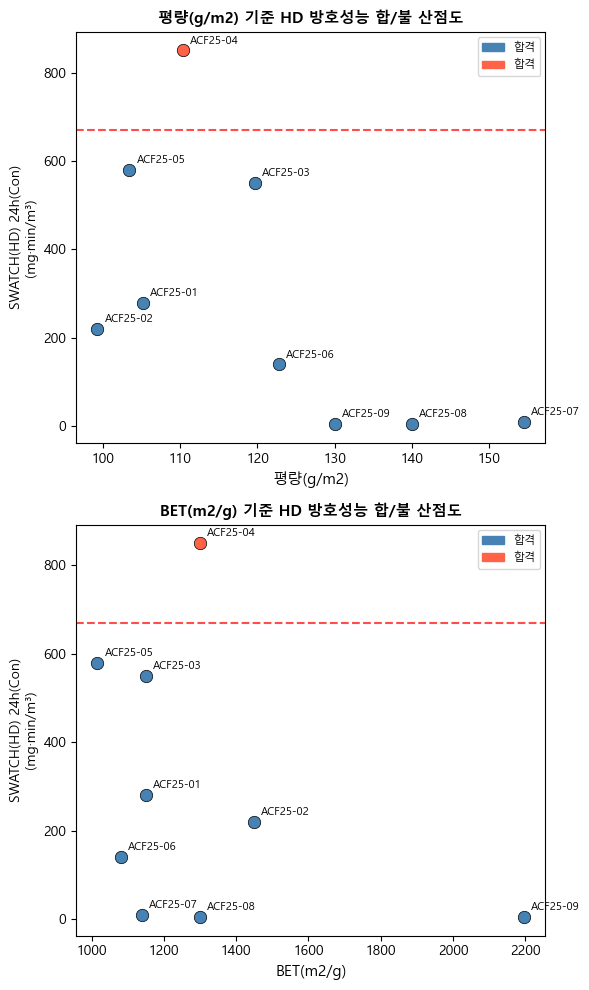

In [ ]:
# fig, axes = plt.subplots(2, 1, figsize=(6,10))

# pairs = [
#     # ('평량(g/m2)', 'SWATCH(GD) 24h(Con)', 'GD 방호성능', 'steelblue', GD_base),
#     ('평량(g/m2)', 'SWATCH(HD) 24h(Con)', 'HD 방호성능', 'darkorange', HD_base),
#     # ('BET(m2/g)',  'SWATCH(GD) 24h(Con)', 'GD 방호성능', 'seagreen',  GD_base),
#     ('BET(m2/g)',  'SWATCH(HD) 24h(Con)', 'HD 방호성능', 'mediumpurple', HD_base),
# ]

# for ax, (x_col, y_col, y_label, color, lim) in zip(axes.flat, pairs):
#     x = df[x_col]
#     y = df[y_col]

#     slope, intercept, r, p, se = stats.linregress(x, y)

#     # x_line = np.linspace(x.min(), x.max(), 100)
#     # y_line = slope * x_line + intercept
#     # ax.plot(x_line, y_line, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)

#     for _, row in df.iterrows():
#         c = 'steelblue' if row[y_col] <= lim else 'tomato'
#         ax.scatter(row[x_col], row[y_col], color=c, s=80, edgecolors='black', linewidths=0.5)
#         ax.annotate(row['Sample'], (row[x_col], row[y_col]),
#             textcoords='offset points', xytext=(5, 5), fontsize=8)

#     # 기준선
#     ax.axhline(lim, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'기준={lim}')

#     # 레이블
#     ax.set_xlabel(x_col, fontsize=11)
#     ax.set_ylabel(y_col + f'\n(mg·min/m³)', fontsize=10)
#     ax.set_title(f'{x_col} 기준 {y_label} 합/불 산점도', fontsize=11, fontweight='bold')

#     pass_p = mpatches.Patch(color='steelblue', label='합격')
#     fail_p = mpatches.Patch(color='tomato', label='합격')
#     ax.legend(handles=[pass_p, fail_p], fontsize=8, loc='upper right')

# # plt.suptitle('X 변수 vs Y 변수 산점도', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

# 상관계수 행렬 (Heatmap)

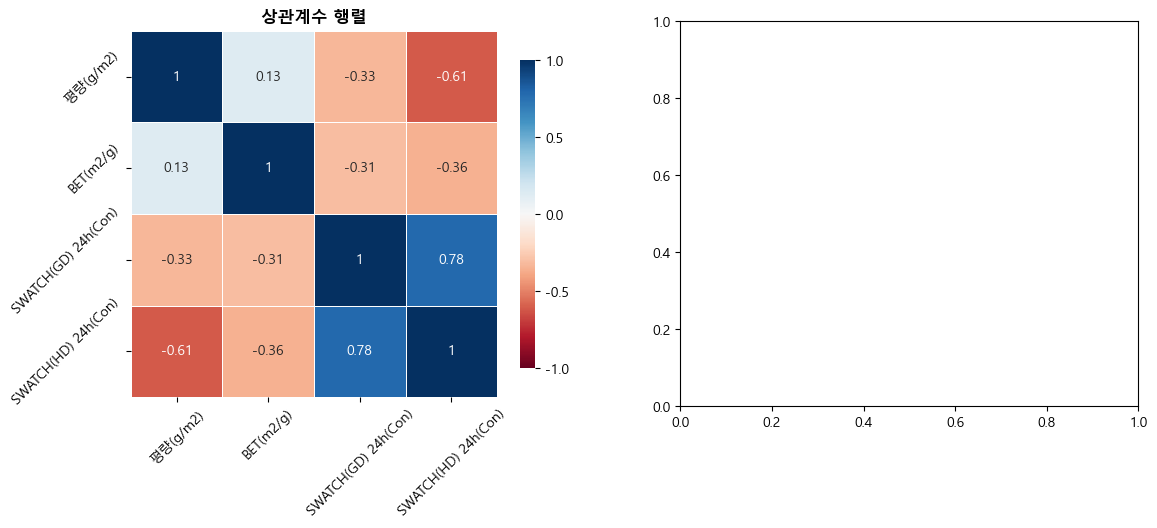

In [224]:
cols = df.columns[1:5]
corr = df[cols].corr()
corr

# p-value
p_mat = pd.DataFrame(np.ones((4,4)), index=cols, columns=cols)
for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        if i != j:
            _, p = stats.pearsonr(df[c1], df[c2])
            p_mat.loc[c1, c2] = p
            
fig, axes = plt.subplots(1, 2, figsize=(13,5))

# 상관계수 Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, cmap='RdBu', center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8, 'ticks': [-1, -0.5, 0.0, 0.5, 1]})
axes[0].set_title('상관계수 행렬', fontsize=12, fontweight='bold')
axes[0].tick_params(rotation=45)

# 2D 합/불 시각화

In [225]:
GD_base

357

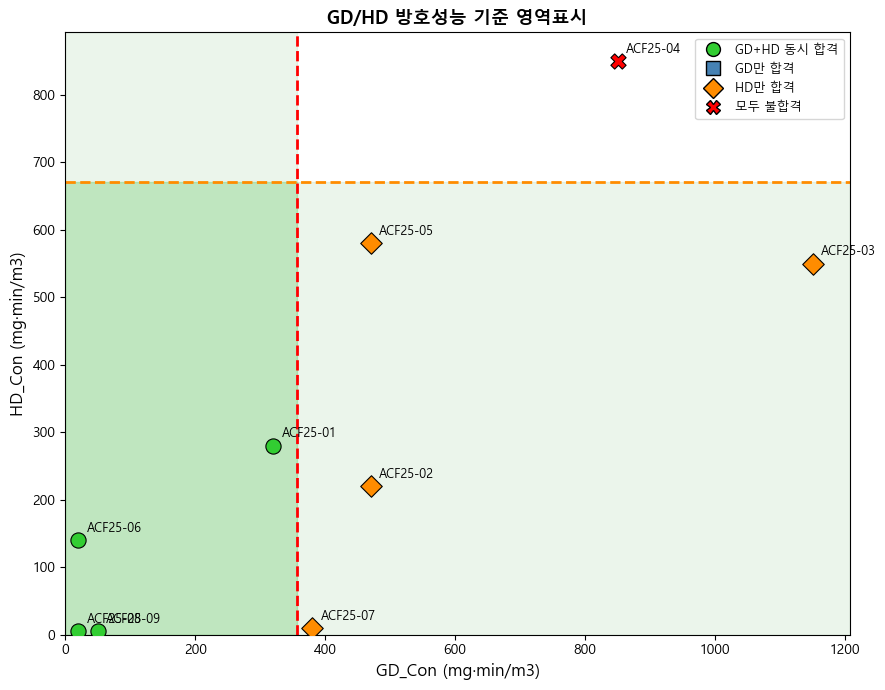

In [226]:
fig, ax = plt.subplots(figsize=(9,7))

# 합격
ax.axhspan(0, HD_base, xmin=0, alpha=0.08, color='green')
ax.axvspan(0, GD_base, alpha=0.08, color='green')
ax.fill_betweenx([0, HD_base], 0, GD_base, alpha=0.15, color='limegreen', label='GD+HD 동시 합격')

# 기준선
ax.axvline(GD_base, color='red', linestyle='--', linewidth=2, label=f'GD 기준 = {GD_base}')
ax.axhline(HD_base, color='darkorange', linestyle='--', linewidth=2, label=f'HD 기준 = {HD_base}')

# point
for _, row in df.iterrows():
    both = (row['SWATCH(GD) 24h(Con)'] <= GD_base) and (row['SWATCH(HD) 24h(Con)'] <= HD_base)
    gd_only = (row['SWATCH(GD) 24h(Con)'] <= GD_base) and (row['SWATCH(HD) 24h(Con)'] > HD_base)
    hd_only = (row['SWATCH(GD) 24h(Con)'] > GD_base) and (row['SWATCH(HD) 24h(Con)'] <= HD_base)
    
    if both:
        c, marker, label = 'limegreen', 'o', 'GD+HD 합격'
    elif gd_only:
        c, marker, label = 'steelblue', 's', 'GD만 합격'
    elif hd_only:
        c, marker, label = 'darkorange', 'D', 'HD만 합격'
    else:
        c, marker, label = 'red', 'X', 'GD+HD 불합격'

    ax.scatter(row['SWATCH(GD) 24h(Con)'], row['SWATCH(HD) 24h(Con)'], color=c, marker=marker,
               s=120, zorder=5, edgecolors='black', linewidths=0.8)
    ax.annotate(row['Sample'], (row['SWATCH(GD) 24h(Con)'], row['SWATCH(HD) 24h(Con)']),
                textcoords='offset points', xytext=(6, 6), fontsize=9)
    

    legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen',  markersize=10, label='GD+HD 동시 합격', markeredgecolor='black'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='steelblue',  markersize=10, label='GD만 합격',       markeredgecolor='black'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='darkorange', markersize=10, label='HD만 합격',       markeredgecolor='black'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='red',        markersize=10, label='모두 불합격',     markeredgecolor='black'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

ax.set_xlabel('GD_Con (mg·min/m3)', fontsize=12)
ax.set_ylabel('HD_Con (mg·min/m3)', fontsize=12)
ax.set_title('GD/HD 방호성능 기준 영역표시', fontsize=13, fontweight='bold')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# 3D 시각화

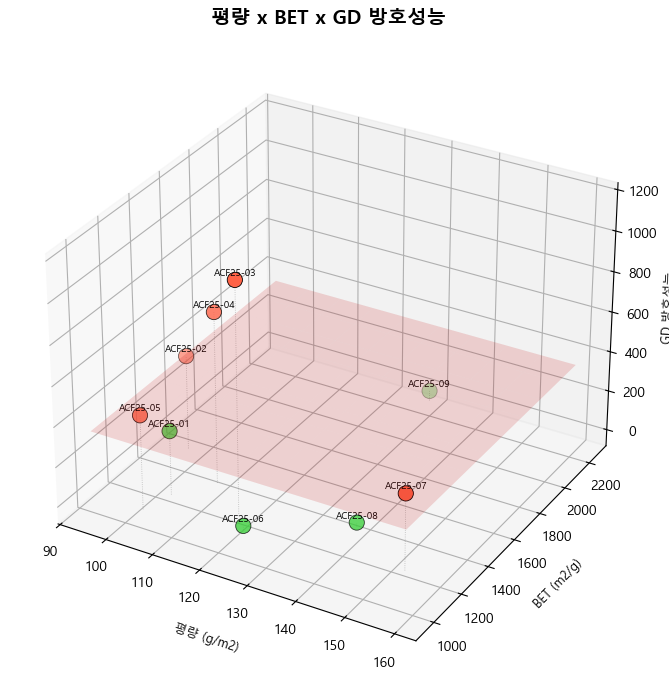

In [227]:
fig = plt.figure(figsize=(16,7))

for idx, (y_col, lim, cmap_name, title) in enumerate([
    ('SWATCH(GD) 24h(Con)', GD_base, 'RdYlGn_r', 'GD 방호성능'),
    # ('SWATCH(HD) 24h(Con)', HD_base, 'RdYlGn_r', 'HD 방호성능'),
]):
    ax = fig.add_subplot(1, 1, idx+1, projection='3d')

    x = df['평량(g/m2)'].values
    y = df['BET(m2/g)'].values
    z = df[y_col].values

    colors = ['limegreen' if v <= lim else 'tomato' for v in z]
    sizes = [120] * len(z)

    sc = ax.scatter(x, y, z, c=colors, s=sizes,
                    edgecolors='black', linewidths=0.6, depthshade=True)

    # 기준 평면
    xx, yy = np.meshgrid(
        np.linspace(x.min() - 5,  x.max() + 5,  10),
        np.linspace(y.min() - 50, y.max() + 50, 10)
    )
    zz = np.full_like(xx, lim)
    ax.plot_surface(xx, yy, zz, alpha=0.15, color='red')

    # 바닥에 수직 투영선
    for xi, yi, zi in zip(x, y, z):
        ax.plot([xi, xi], [yi, yi], [0, zi], color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

    # 샘플 레이블
    for _, row in df.iterrows():
        ax.text(row['평량(g/m2)'], row['BET(m2/g)'], row[y_col] + 20,
                row['Sample'], fontsize=7, ha='center')
    ax.set_xlabel('평량 (g/m2)', fontsize=9, labelpad=8)
    ax.set_ylabel('BET (m2/g)',  fontsize=9, labelpad=8)
    ax.set_zlabel(f'{title}\n(mg·min/m³)', fontsize=9, labelpad=8)
    # ax.set_title(f'평량 x BET x 방호성능',
    #              fontsize=11, fontweight='bold', pad=12)
    # ax.view_init(elev=25, azim=-50)

plt.suptitle('평량 x BET x GD 방호성능', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

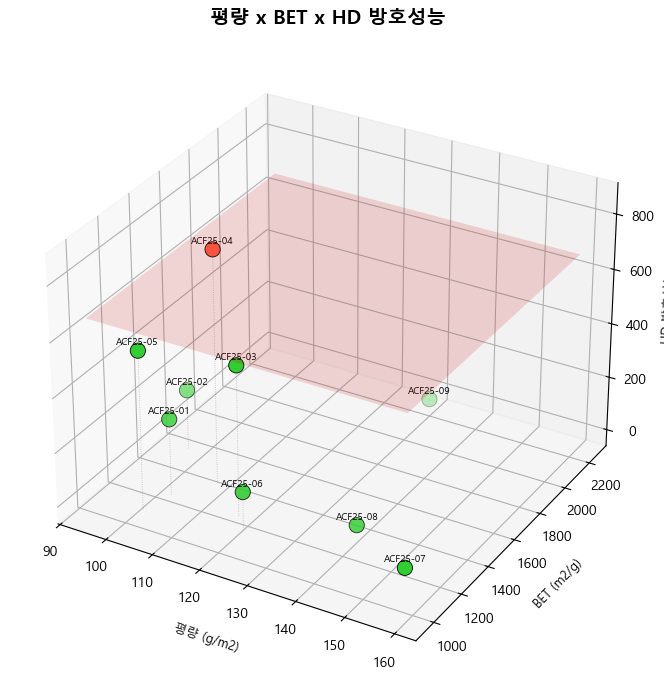

In [228]:
fig = plt.figure(figsize=(16,7))

for idx, (y_col, lim, cmap_name, title) in enumerate([
    # ('SWATCH(GD) 24h(Con)', GD_base, 'RdYlGn_r', 'GD 방호성능'),
    ('SWATCH(HD) 24h(Con)', HD_base, 'RdYlGn_r', 'HD 방호성능'),
]):
    ax = fig.add_subplot(1, 1, idx+1, projection='3d')

    x = df['평량(g/m2)'].values
    y = df['BET(m2/g)'].values
    z = df[y_col].values

    colors = ['limegreen' if v <= lim else 'tomato' for v in z]
    sizes = [120] * len(z)

    sc = ax.scatter(x, y, z, c=colors, s=sizes,
                    edgecolors='black', linewidths=0.6, depthshade=True)

    # 기준 평면
    xx, yy = np.meshgrid(
        np.linspace(x.min() - 5,  x.max() + 5,  10),
        np.linspace(y.min() - 50, y.max() + 50, 10)
    )
    zz = np.full_like(xx, lim)
    ax.plot_surface(xx, yy, zz, alpha=0.15, color='red')

    # 바닥에 수직 투영선
    for xi, yi, zi in zip(x, y, z):
        ax.plot([xi, xi], [yi, yi], [0, zi], color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

    # 샘플 레이블
    for _, row in df.iterrows():
        ax.text(row['평량(g/m2)'], row['BET(m2/g)'], row[y_col] + 20,
                row['Sample'], fontsize=7, ha='center')
    ax.set_xlabel('평량 (g/m2)', fontsize=9, labelpad=8)
    ax.set_ylabel('BET (m2/g)',  fontsize=9, labelpad=8)
    ax.set_zlabel(f'{title}\n(mg·min/m³)', fontsize=9, labelpad=8)
    # ax.set_title(f'평량 x BET x 방호성능',
    #              fontsize=11, fontweight='bold', pad=12)
    # ax.view_init(elev=25, azim=-50)

plt.suptitle('평량 x BET x HD 방호성능', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Multiple Linear Regression

In [229]:
df

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con),GD_PASS,HD_PASS,All_PASS
0,ACF25-01,105.20,1150,320,280,True,True,True
1,ACF25-02,99.30,1450,470,220,False,True,False
2,ACF25-03,119.70,1150,1150,550,False,True,False
3,ACF25-04,110.40,1300,850,850,False,False,False
4,ACF25-05,103.44,1016,470,580,False,True,False
5,ACF25-06,122.83,1080,20,140,True,True,True
6,ACF25-07,154.49,1139,380,10,False,True,False
7,ACF25-08,140.00,1300,20,5,True,True,True
8,ACF25-09,130.00,2197,50,5,True,True,True


[557.08464971 507.3918789  466.06436567 481.07858741 606.87140838
 466.65321462 250.85850562 295.27166274  98.72572695]
                               OLS Regression Results                               
Dep. Variable:     Q("SWATCH(GD) 24h(Con)")   R-squared:                       0.182
Model:                                  OLS   Adj. R-squared:                 -0.091
Method:                       Least Squares   F-statistic:                    0.6664
Date:                      Sun, 19 Apr 2026   Prob (F-statistic):              0.548
Time:                              17:28:36   Log-Likelihood:                -64.937
No. Observations:                         9   AIC:                             135.9
Df Residuals:                             6   BIC:                             136.5
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                     coef    s

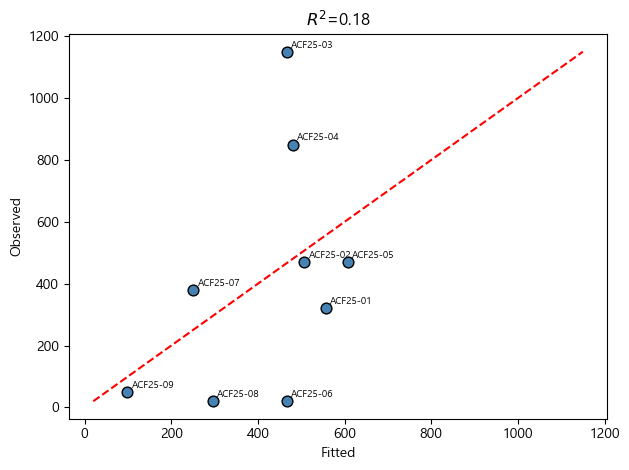

In [230]:
samples = df['Sample'].tolist()

model1 = smf.ols('Q("SWATCH(GD) 24h(Con)") ~ Q("평량(g/m2)")+Q("BET(m2/g)")', data = df)
result1 = model1.fit()
pred1 = result1.predict()
print(pred1)
print(result1.summary())

# Pred vs. Observed
fig, ax = plt.subplots()

y_observed = df['SWATCH(GD) 24h(Con)']

ax.scatter(pred1, y_observed, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([y_observed.min(), y_observed.max()], [y_observed.min(), y_observed.max()],
        linestyle='--', color='red')
for idx, (xi, yi) in enumerate(zip(pred1, y_observed)):
    ax.annotate(samples[idx], (xi, yi),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={result1.rsquared:.2f}')

plt.tight_layout()
plt.show()

[477.63195748 461.94377834 339.88740398 392.36592922 526.39335986
 326.89197104  12.02579046 111.17704758  -8.31723795]
                               OLS Regression Results                               
Dep. Variable:     Q("SWATCH(HD) 24h(Con)")   R-squared:                       0.454
Model:                                  OLS   Adj. R-squared:                  0.272
Method:                       Least Squares   F-statistic:                     2.496
Date:                      Sun, 19 Apr 2026   Prob (F-statistic):              0.163
Time:                              17:28:36   Log-Likelihood:                -60.934
No. Observations:                         9   AIC:                             127.9
Df Residuals:                             6   BIC:                             128.5
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                     coef    s

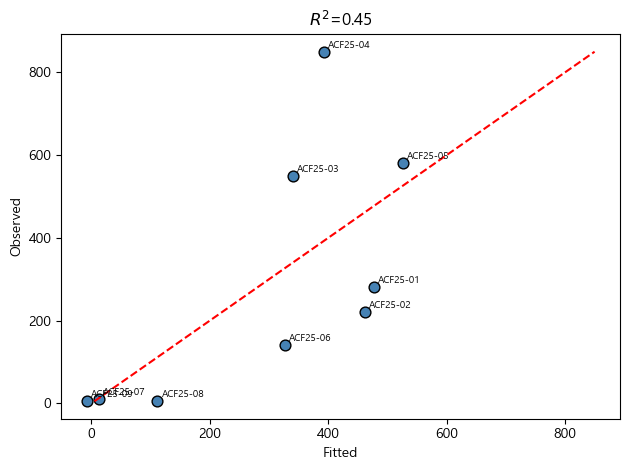

In [231]:
samples = df['Sample'].tolist()
model2 = smf.ols('Q("SWATCH(HD) 24h(Con)") ~ Q("평량(g/m2)")+Q("BET(m2/g)")', data = df)
result2 = model2.fit()
pred2 = result2.predict()
print(pred2)
print(result2.summary())

# Pred vs. Observed
fig, ax = plt.subplots()

y_observed = df['SWATCH(HD) 24h(Con)']

ax.scatter(pred2, y_observed, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([y_observed.min(), y_observed.max()], [y_observed.min(), y_observed.max()],
        linestyle='--', color='red')
for idx, (xi, yi) in enumerate(zip(pred2, y_observed)):
    ax.annotate(samples[idx], (xi, yi),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={result2.rsquared:.2f}')

plt.tight_layout()
plt.show()

0.18176393937605295


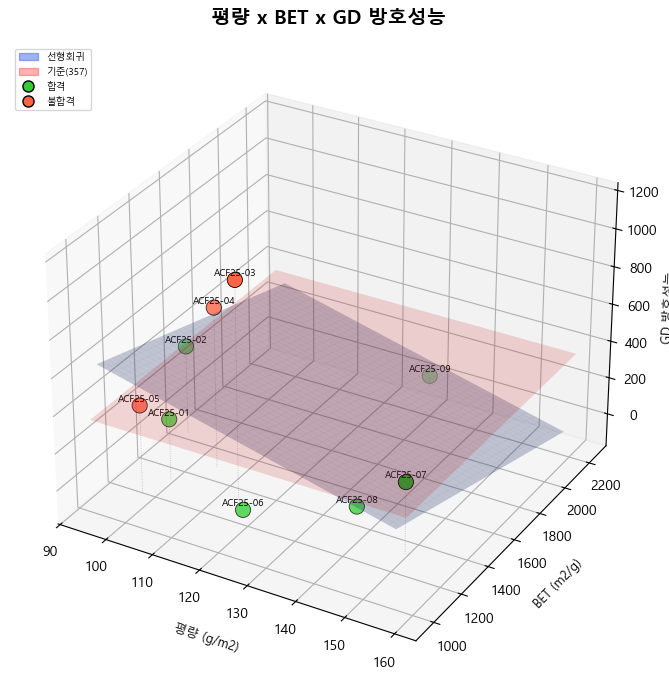

In [310]:
fig = plt.figure(figsize=(16,7))
y_col = 'SWATCH(GD) 24h(Con)'
lim = GD_base
cmap_name = 'RdYlGn_r'
title = 'GD 방호성능'


ax = fig.add_subplot(1, 1, 1, projection='3d')

x1 = df['평량(g/m2)'].values
x2 = df['BET(m2/g)'].values
y1 = df[y_col].values

b0, b1, b2 = result1.params
y_pred = pred1
r2 = result1.rsquared
print(r2)


# 회귀 평면 생성
x1_grid = np.linspace(x1.min() - 3,  x1.max() + 3,  40)
x2_grid = np.linspace(x2.min() - 50, x2.max() + 50, 40)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)
Zg = b0 + b1 * X1g + b2 * X2g


# 회귀 평면 (파란색)
ax.plot_surface(X1g, X2g, Zg, alpha=0.25, color='royalblue', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg, alpha=0.08, color='navy', linewidth=0.3)



colors = ['limegreen' if v <= lim else 'tomato' for v in z]
sizes = [120] * len(z)

sc = ax.scatter(x1, x2, y1, c=colors, s=sizes,
                edgecolors='black', linewidths=0.6, depthshade=True)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min() - 5,  x1.max() + 5,  10),
    np.linspace(x2.min() - 50, x2.max() + 50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red')

# 바닥에 수직 투영선
for xi, yi, zi in zip(x1, x2, y1):
    ax.plot([xi, xi], [yi, yi], [0, zi], color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 레이블
for _, row in df.iterrows():
    ax.text(row['평량(g/m2)'], row['BET(m2/g)'], row[y_col] + 20,
            row['Sample'], fontsize=7, ha='center')
ax.set_xlabel('평량 (g/m2)', fontsize=9, labelpad=8)
ax.set_ylabel('BET (m2/g)',  fontsize=9, labelpad=8)
ax.set_zlabel(f'{title}\n(mg·min/m³)', fontsize=9, labelpad=8)

leg = [
    mpatches.Patch(color='royalblue', alpha=0.5, label='선형회귀'),
    mpatches.Patch(color='red',       alpha=0.3, label=f'기준({lim})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='limegreen',
            markersize=8, label='합격', markeredgecolor='black'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
            markersize=8, label='불합격', markeredgecolor='black'),
]
ax.legend(handles=leg, fontsize=7, loc='upper left')


plt.suptitle('평량 x BET x GD 방호성능', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

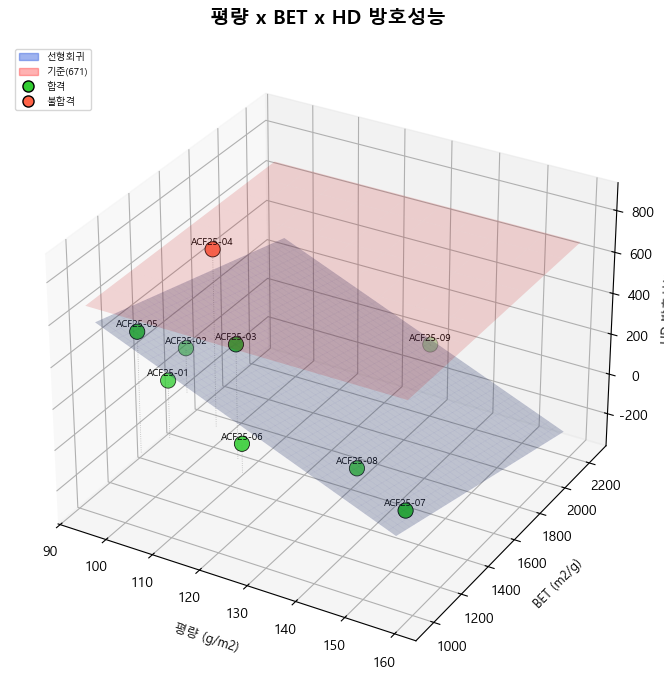

In [311]:
fig = plt.figure(figsize=(16,7))
y_col = 'SWATCH(HD) 24h(Con)'
lim = HD_base
cmap_name = 'RdYlGn_r'
title = 'HD 방호성능'


ax = fig.add_subplot(1, 1, 1, projection='3d')

x1 = df['평량(g/m2)'].values
x2 = df['BET(m2/g)'].values
y2 = df[y_col].values

b0, b1, b2 = result2.params
y_pred = pred2
r2 = result2.rsquared


# 회귀 평면 생성
x1_grid = np.linspace(x1.min() - 3,  x1.max() + 3,  40)
x2_grid = np.linspace(x2.min() - 50, x2.max() + 50, 40)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)
Zg = b0 + b1 * X1g + b2 * X2g


# 회귀 평면 (파란색)
ax.plot_surface(X1g, X2g, Zg, alpha=0.25, color='royalblue', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg, alpha=0.08, color='navy', linewidth=0.3)



colors = ['limegreen' if v <= lim else 'tomato' for v in z]
sizes = [120] * len(z)

sc = ax.scatter(x1, x2, y2, c=colors, s=sizes,
                edgecolors='black', linewidths=0.6, depthshade=True)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min() - 5,  x1.max() + 5,  10),
    np.linspace(x2.min() - 50, x2.max() + 50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red')

# 바닥에 수직 투영선
for xi, yi, zi in zip(x1, x2, y2):
    ax.plot([xi, xi], [yi, yi], [0, zi], color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 레이블
for _, row in df.iterrows():
    ax.text(row['평량(g/m2)'], row['BET(m2/g)'], row[y_col] + 20,
            row['Sample'], fontsize=7, ha='center')
ax.set_xlabel('평량 (g/m2)', fontsize=9, labelpad=8)
ax.set_ylabel('BET (m2/g)',  fontsize=9, labelpad=8)
ax.set_zlabel(f'{title}\n(mg·min/m³)', fontsize=9, labelpad=8)

leg = [
    mpatches.Patch(color='royalblue', alpha=0.5, label='선형회귀'),
    mpatches.Patch(color='red',       alpha=0.3, label=f'기준({lim})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='limegreen',
            markersize=8, label='합격', markeredgecolor='black'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
            markersize=8, label='불합격', markeredgecolor='black'),
]
ax.legend(handles=leg, fontsize=7, loc='upper left')


plt.suptitle('평량 x BET x HD 방호성능', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 정규성 가정

In [234]:
from statsmodels.stats.diagnostic import linear_reset
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

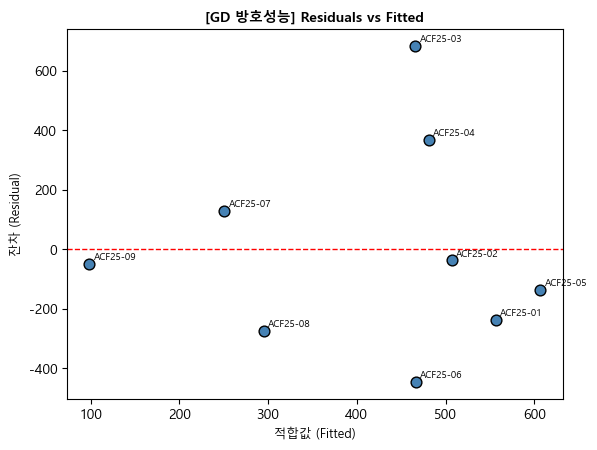

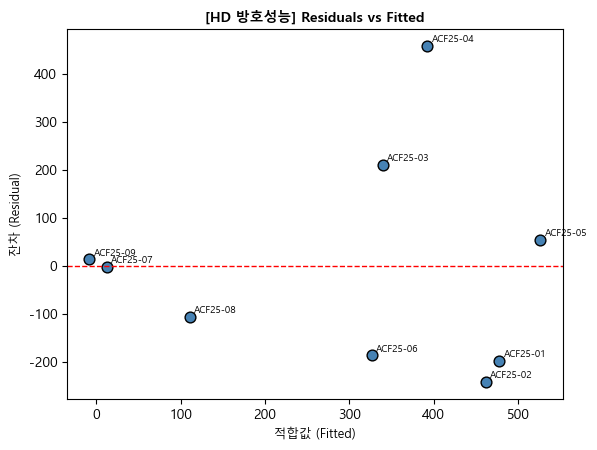

In [235]:
samples = df['Sample'].tolist()
residuals1 = result1.resid
fitted1 = result1.fittedvalues

plt.scatter(fitted1, residuals1, color='steelblue', edgecolors='black', s=60)
plt.axhline(0, color='red', linestyle='--', linewidth=1)

for idx, (xi, yi) in enumerate(zip(fitted1, residuals1)):
    plt.annotate(samples[idx], (xi, yi),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
plt.xlabel('적합값 (Fitted)', fontsize=9)
plt.ylabel('잔차 (Residual)', fontsize=9)
plt.title(f'[GD 방호성능] Residuals vs Fitted', fontsize=10, fontweight='bold')
plt.show()


residuals2 = result2.resid
fitted2 = result2.fittedvalues

plt.scatter(fitted2, residuals2, color='steelblue', edgecolors='black', s=60)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
for idx, (xi, yi) in enumerate(zip(fitted2, residuals2)):
    plt.annotate(samples[idx], (xi, yi),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
plt.xlabel('적합값 (Fitted)', fontsize=9)
plt.ylabel('잔차 (Residual)', fontsize=9)
plt.title(f'[HD 방호성능] Residuals vs Fitted', fontsize=10, fontweight='bold')
plt.show()


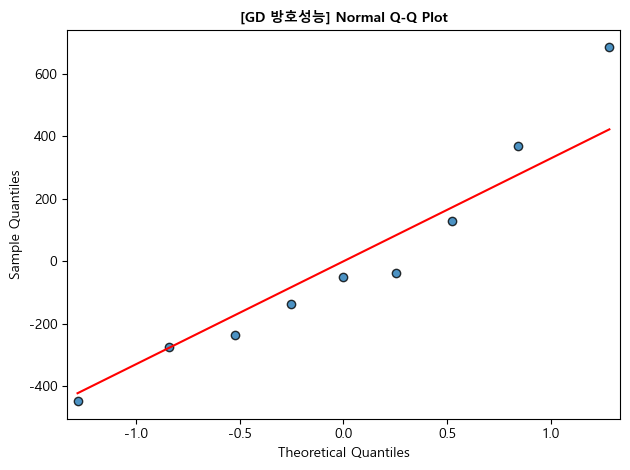

In [236]:

fig, ax = plt.subplots()

pp = ProbPlot(residuals1)
pp.qqplot(line='s', ax=ax, alpha=0.8)

# 점 스타일 수정 (핵심 수정)
for line in ax.get_lines():
    if line.get_linestyle() == 'None':  # 데이터 점
        line.set_color('steelblue')
        line.set_markersize(6)
        line.set_markeredgecolor('black')
for idx, (xi, yi) in enumerate(zip(y1, pred1)):
    plt.annotate(samples[idx], (xi, yi),
                fontsize=7, xytext=(3,3), textcoords='offset points')

# 제목 및 라벨
ax.set_title('[GD 방호성능] Normal Q-Q Plot', fontsize=10, fontweight='bold')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

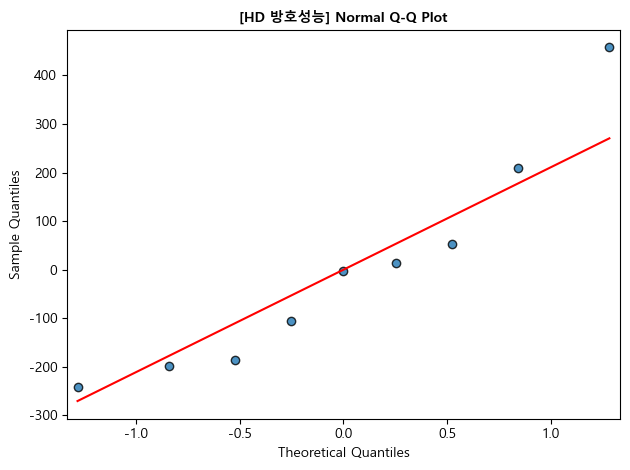

In [237]:

fig, ax = plt.subplots()

pp = ProbPlot(residuals2)
pp.qqplot(line='s', ax=ax, alpha=0.8)

# 점 스타일 수정 (핵심 수정)
for line in ax.get_lines():
    if line.get_linestyle() == 'None':  # 데이터 점
        line.set_color('steelblue')
        line.set_markersize(6)
        line.set_markeredgecolor('black')

# 제목 및 라벨
ax.set_title('[HD 방호성능] Normal Q-Q Plot', fontsize=10, fontweight='bold')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

# cook's distance

[0.21324923 0.31536986 0.135784   0.14973769 0.28226665 0.16741827
 0.59855684 0.25329102 0.88432643]
[0.03974216 0.00193061 0.17452835 0.05785281 0.0210664  0.09888298
 0.12712191 0.0706434  0.32202719]


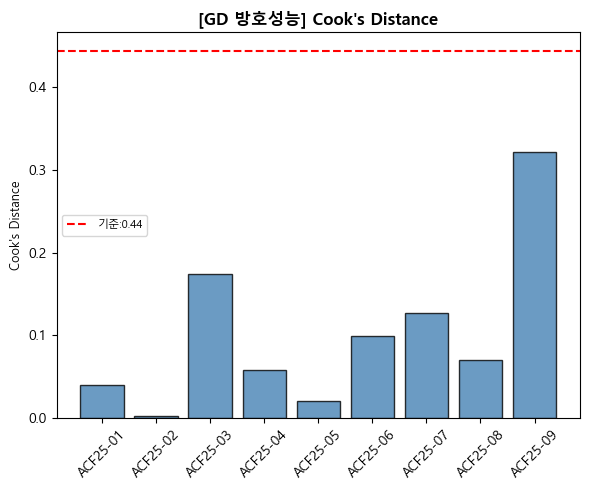

In [270]:
n = df.shape[0]
threshold = 4 / n
samples = df['Sample'].tolist()

cooks_distance1 = result1.get_influence().cooks_distance[0]

bar_colors = ['tomato' if c > threshold else 'steelblue' for c in cooks_distance1]


influence1 = result1.get_influence()

# leverage
print(influence1.hat_matrix_diag)

# Cook's distance
print(influence1.cooks_distance[0])

fig, axes = plt.subplots(1, 1, figsize=(6,5))
axes.bar(samples, cooks_distance1, color=bar_colors, edgecolor='black', alpha=0.8)
axes.axhline(threshold, color='red', linestyle='--', linewidth=1.5,
               label=f'기준:{threshold:.2f}')
# plt.stem(influence.cooks_distance[0])
axes.set_title("[GD 방호성능] Cook's Distance", fontweight='bold')
axes.set_ylabel("Cook's Distance", fontsize=9)
axes.tick_params(axis='x', rotation=45)
axes.legend(fontsize=8)

plt.tight_layout()
plt.show()

[0.21324923 0.31536986 0.135784   0.14973769 0.28226665 0.16741827
 0.59855684 0.25329102 0.88432643]
[6.72097435e-02 1.96716977e-01 4.00878680e-02 2.16654006e-01
 7.86457487e-03 4.21342403e-02 7.61291691e-05 2.55789732e-02
 5.85433344e-02]


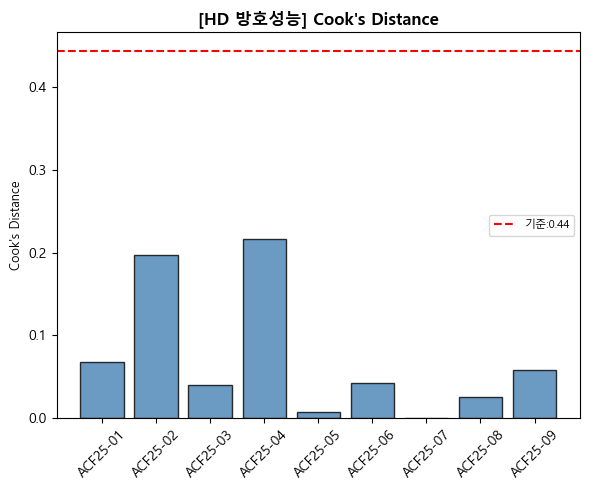

In [271]:
n = df.shape[0]
threshold = 4 / n
samples = df['Sample'].tolist()

cooks_distance2 = result2.get_influence().cooks_distance[0]

bar_colors = ['tomato' if c > threshold else 'steelblue' for c in cooks_distance2]


influence2 = result2.get_influence()

# leverage
print(influence2.hat_matrix_diag)

# Cook's distance
print(influence2.cooks_distance[0])

fig, axes = plt.subplots(1, 1, figsize=(6,5))
axes.bar(samples, cooks_distance2, color=bar_colors, edgecolor='black', alpha=0.8)
axes.axhline(threshold, color='red', linestyle='--', linewidth=1.5,
               label=f'기준:{threshold:.2f}')
# plt.stem(influence.cooks_distance[0])
axes.set_title("[HD 방호성능] Cook's Distance", fontweight='bold')
axes.set_ylabel("Cook's Distance", fontsize=9)
axes.tick_params(axis='x', rotation=45)
axes.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 등분산성

In [244]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test1 = het_breuschpagan(result1.resid, result1.model.exog)
print(bp_test1)

bp_test2 = het_breuschpagan(result2.resid, result2.model.exog)
print(bp_test2)



(0.9114672199531962, 0.6339827012723132, 0.3380590441080917, 0.72590823178196)
(1.3902919586274765, 0.4990015987570844, 0.5480993295940103, 0.604472371926351)


In [258]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = result1.model.exog

for i in range(X.shape[1]):
    print(i, variance_inflation_factor(X, i))

0 58.50296950588993
1 1.015962824398935
2 1.015962824398935


In [259]:
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

vif

,VIF Factor
0,58.502970
1,1.015963
2,1.015963


In [256]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = result2.model.exog

for i in range(X.shape[1]):
    print(i, variance_inflation_factor(X, i))

0 58.50296950588993
1 1.015962824398935
2 1.015962824398935


In [257]:
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

vif

,VIF Factor
0,58.502970
1,1.015963
2,1.015963


In [249]:
robust = result1.get_robustcov_results(cov_type='HC3')

print(result1.bse)        # 일반 표준오차
print()
print(robust.bse)        # robust 표준오차

Intercept         1027.522441
Q("평량(g/m2)")        7.805611
Q("BET(m2/g)")       0.400975
dtype: float64

[8.40300745e+02 5.72110488e+00 4.13919148e-01]


In [260]:
robust = result1.get_robustcov_results(cov_type='HC3')

print("OLS SE:", result1.bse)
print("Robust SE:", robust.bse)

OLS SE: Intercept         1027.522441
Q("평량(g/m2)")        7.805611
Q("BET(m2/g)")       0.400975
dtype: float64
Robust SE: [8.40300745e+02 5.72110488e+00 4.13919148e-01]


Linear R^2 = 0.18176393937605295
Spline R^2 = 0.23373871390242384


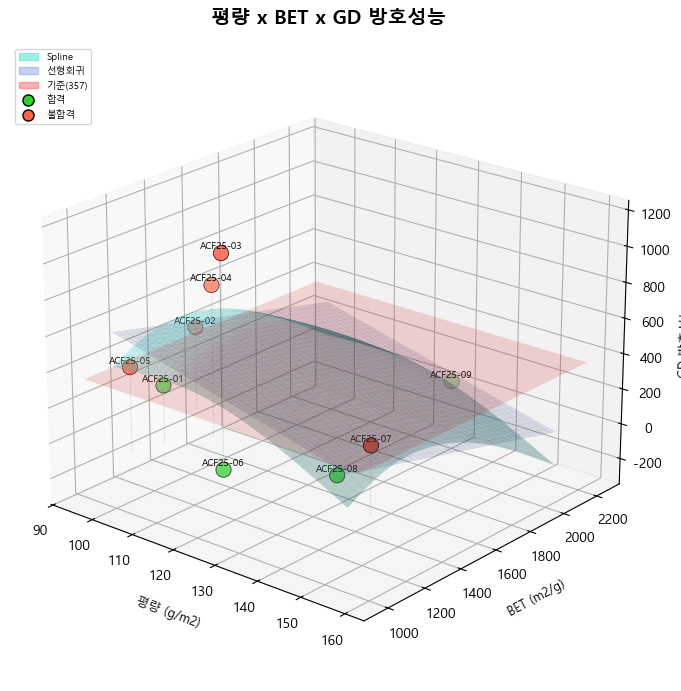

In [312]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.patches as mpatches

from matplotlib.lines import Line2D
from patsy import dmatrix, build_design_matrices

fig = plt.figure(figsize=(16, 7))
y_col = 'SWATCH(GD) 24h(Con)'
lim = GD_base
title = 'GD 방호성능'

ax = fig.add_subplot(1, 1, 1, projection='3d')

# 원본 데이터
x1 = df['평량(g/m2)'].values
x2 = df['BET(m2/g)'].values
y1 = df[y_col].values

# ---------------------------
# 1. 선형 회귀면
# ---------------------------
b0, b1, b2 = result1.params
y_pred = pred1
r2 = result1.rsquared
print('Linear R^2 =', r2)

x1_grid = np.linspace(x1.min(), x1.max(), 40)
x2_grid = np.linspace(x2.min(), x2.max(), 40)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)

Zg = b0 + b1 * X1g + b2 * X2g

ax.plot_surface(X1g, X2g, Zg, alpha=0.12, color='royalblue', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg, alpha=0.10, color='navy', linewidth=0.3)

# ---------------------------
# 2. 스플라인 회귀 적합
# ---------------------------
k1 = float(np.median(x1))
k2 = float(np.median(x2))

formula = (
    f"cr(평량, knots=[{k1}], lower_bound={x1.min()}, upper_bound={x1.max()})"
    f" + cr(BET, knots=[{k2}], lower_bound={x2.min()}, upper_bound={x2.max()})"
)

# 학습용 design matrix
train_dict = {'평량': x1, 'BET': x2}
X_spline = dmatrix(formula, train_dict, return_type='dataframe')

model_spline = sm.OLS(y1, X_spline).fit()
print('Spline R^2 =', model_spline.rsquared)

# ---------------------------
# 3. 스플라인 회귀면 예측
# ---------------------------
# 여기서는 반드시 grid 데이터를 넣어야 함
grid_dict = {'평량': X1g.ravel(), 'BET': X2g.ravel()}

# 학습 때의 design_info를 이용해 grid 변환
Xg_spline = build_design_matrices(
    [X_spline.design_info],
    grid_dict
)[0]

pred_grid = model_spline.predict(Xg_spline)
Zg_spl = np.asarray(pred_grid).reshape(X1g.shape)

# ax.plot_surface(X1g, X2g, Zg_spl, alpha=0.28, color='royalblue', edgecolor='none')
# ax.plot_wireframe(X1g, X2g, Zg_spl, alpha=0.15, color='navy', linewidth=0.3)
ax.plot_surface(X1g, X2g, Zg_spl, alpha=0.28, color='turquoise', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg_spl, alpha=0.15, color='teal', linewidth=0.3)

# ---------------------------
# 4. 실제 점 표시
# ---------------------------
colors = ['limegreen' if v <= lim else 'tomato' for v in y1]
sizes = [120] * len(y1)

ax.scatter(
    x1, x2, y1,
    c=colors, s=sizes,
    edgecolors='black', linewidths=0.6, depthshade=True
)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min() - 5,  x1.max() + 5,  10),
    np.linspace(x2.min() - 50, x2.max() + 50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red', edgecolor='none')

# 바닥에 수직 투영선
for xi, yi, zi in zip(x1, x2, y1):
    ax.plot([xi, xi], [yi, yi], [0, zi],
            color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 레이블
for _, row in df.iterrows():
    ax.text(
        row['평량(g/m2)'],
        row['BET(m2/g)'],
        row[y_col] + 20,
        row['Sample'],
        fontsize=7,
        ha='center'
    )

# 축 라벨
ax.set_xlabel('평량 (g/m2)', fontsize=9, labelpad=8)
ax.set_ylabel('BET (m2/g)', fontsize=9, labelpad=8)
ax.set_zlabel(f'{title}\n(mg·min/m³)', fontsize=9, labelpad=8)

# 범례
leg = [
    mpatches.Patch(color='turquoise', alpha=0.5, label='Spline'),
    mpatches.Patch(color='royalblue', alpha=0.3, label='선형회귀'),
    mpatches.Patch(color='red', alpha=0.3, label=f'기준({lim})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen',
           markersize=8, label='합격', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
           markersize=8, label='불합격', markeredgecolor='black'),
]
ax.legend(handles=leg, fontsize=7, loc='upper left')

ax.view_init(elev=22, azim=-50)

plt.suptitle('평량 x BET x GD 방호성능', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Linear R^2 = 0.45412210887584614
Spline R^2 = 0.4996383804531854


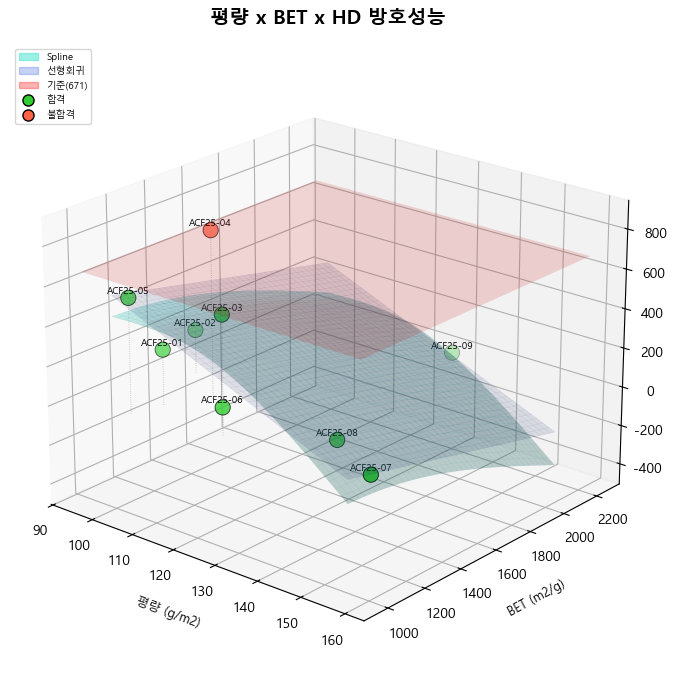

In [313]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.patches as mpatches

from matplotlib.lines import Line2D
from patsy import dmatrix, build_design_matrices

fig = plt.figure(figsize=(16, 7))
y_col = 'SWATCH(HD) 24h(Con)'
lim = HD_base
title = 'HD 방호성능'

ax = fig.add_subplot(1, 1, 1, projection='3d')

# 원본 데이터
x1 = df['평량(g/m2)'].values
x2 = df['BET(m2/g)'].values
y1 = df[y_col].values

# ---------------------------
# 1. 선형 회귀면
# ---------------------------
b0, b1, b2 = result2.params
y_pred = pred2
r2 = result2.rsquared
print('Linear R^2 =', r2)

x1_grid = np.linspace(x1.min(), x1.max(), 40)
x2_grid = np.linspace(x2.min(), x2.max(), 40)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)

Zg = b0 + b1 * X1g + b2 * X2g

ax.plot_surface(X1g, X2g, Zg, alpha=0.12, color='royalblue', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg, alpha=0.10, color='navy', linewidth=0.3)

# ---------------------------
# 2. 스플라인 회귀 적합
# ---------------------------
k1 = float(np.median(x1))
k2 = float(np.median(x2))

formula = (
    f"cr(평량, knots=[{k1}], lower_bound={x1.min()}, upper_bound={x1.max()})"
    f" + cr(BET, knots=[{k2}], lower_bound={x2.min()}, upper_bound={x2.max()})"
)

# 학습용 design matrix
train_dict = {'평량': x1, 'BET': x2}
X_spline = dmatrix(formula, train_dict, return_type='dataframe')

model_spline = sm.OLS(y1, X_spline).fit()
print('Spline R^2 =', model_spline.rsquared)

# ---------------------------
# 3. 스플라인 회귀면 예측
# ---------------------------
# 여기서는 반드시 grid 데이터를 넣어야 함
grid_dict = {'평량': X1g.ravel(), 'BET': X2g.ravel()}

# 학습 때의 design_info를 이용해 grid 변환
Xg_spline = build_design_matrices(
    [X_spline.design_info],
    grid_dict
)[0]

pred_grid = model_spline.predict(Xg_spline)
Zg_spl = np.asarray(pred_grid).reshape(X1g.shape)

ax.plot_surface(X1g, X2g, Zg_spl, alpha=0.28, color='turquoise', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg_spl, alpha=0.15, color='teal', linewidth=0.3)
# ---------------------------
# 4. 실제 점 표시
# ---------------------------
colors = ['limegreen' if v <= lim else 'tomato' for v in y1]
sizes = [120] * len(y1)

ax.scatter(
    x1, x2, y1,
    c=colors, s=sizes,
    edgecolors='black', linewidths=0.6, depthshade=True
)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min() - 5,  x1.max() + 5,  10),
    np.linspace(x2.min() - 50, x2.max() + 50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red', edgecolor='none')

# 바닥에 수직 투영선
for xi, yi, zi in zip(x1, x2, y1):
    ax.plot([xi, xi], [yi, yi], [0, zi],
            color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 레이블
for _, row in df.iterrows():
    ax.text(
        row['평량(g/m2)'],
        row['BET(m2/g)'],
        row[y_col] + 20,
        row['Sample'],
        fontsize=7,
        ha='center'
    )

# 축 라벨
ax.set_xlabel('평량 (g/m2)', fontsize=9, labelpad=8)
ax.set_ylabel('BET (m2/g)', fontsize=9, labelpad=8)
ax.set_zlabel(f'{title}\n(mg·min/m³)', fontsize=9, labelpad=8)


# 범례
leg = [
    mpatches.Patch(color='turquoise', alpha=0.5, label='Spline'),
    mpatches.Patch(color='royalblue', alpha=0.3, label='선형회귀'),
    mpatches.Patch(color='red', alpha=0.3, label=f'기준({lim})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen',
           markersize=8, label='합격', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
           markersize=8, label='불합격', markeredgecolor='black'),
]
ax.legend(handles=leg, fontsize=7, loc='upper left')

ax.view_init(elev=22, azim=-50)

plt.suptitle('평량 x BET x HD 방호성능', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Linear R^2 = 0.18176393937605295
Spline R^2 = 0.23373871390242384


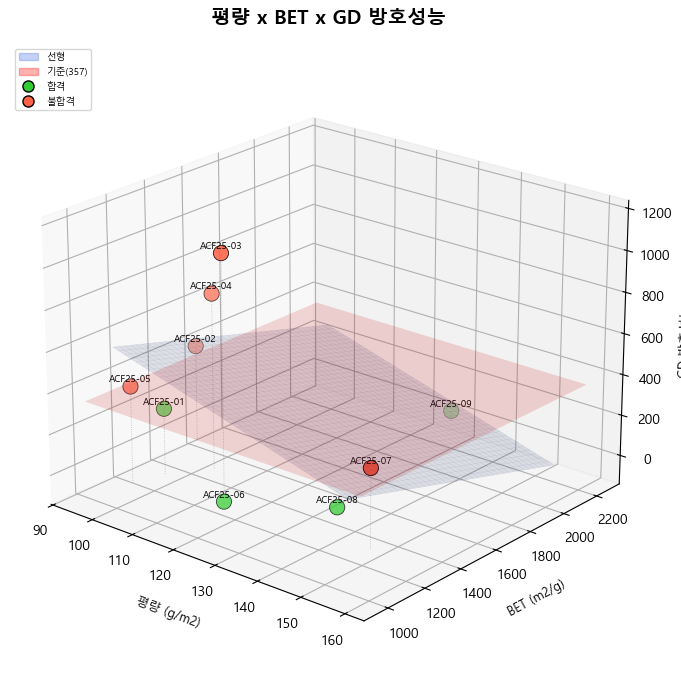

In [326]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.patches as mpatches

from matplotlib.lines import Line2D
from patsy import dmatrix, build_design_matrices

fig = plt.figure(figsize=(16, 7))
y_col = 'SWATCH(GD) 24h(Con)'
lim = GD_base
title = 'GD 방호성능'

ax = fig.add_subplot(1, 1, 1, projection='3d')

# 원본 데이터
x1 = df['평량(g/m2)'].values
x2 = df['BET(m2/g)'].values
y1 = df[y_col].values

# ---------------------------
# 1. 선형 회귀면
# ---------------------------
b0, b1, b2 = result1.params
y_pred = pred1
r2 = result1.rsquared
print('Linear R^2 =', r2)

x1_grid = np.linspace(x1.min(), x1.max(), 40)
x2_grid = np.linspace(x2.min(), x2.max(), 40)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)

Zg = b0 + b1 * X1g + b2 * X2g

ax.plot_surface(X1g, X2g, Zg, alpha=0.12, color='royalblue', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg, alpha=0.10, color='navy', linewidth=0.3)

# ---------------------------
# 2. 스플라인 회귀 적합
# ---------------------------
k1 = float(np.median(x1))
k2 = float(np.median(x2))

formula = (
    f"cr(평량, knots=[{k1}], lower_bound={x1.min()}, upper_bound={x1.max()})"
    f" + cr(BET, knots=[{k2}], lower_bound={x2.min()}, upper_bound={x2.max()})"
)

# 학습용 design matrix
train_dict = {'평량': x1, 'BET': x2}
X_spline = dmatrix(formula, train_dict, return_type='dataframe')

model_spline = sm.OLS(y1, X_spline).fit()
print('Spline R^2 =', model_spline.rsquared)

# ---------------------------
# 3. 스플라인 회귀면 예측
# ---------------------------
# 여기서는 반드시 grid 데이터를 넣어야 함
grid_dict = {'평량': X1g.ravel(), 'BET': X2g.ravel()}

# 학습 때의 design_info를 이용해 grid 변환
Xg_spline = build_design_matrices(
    [X_spline.design_info],
    grid_dict
)[0]

pred_grid = model_spline.predict(Xg_spline)
Zg_spl = np.asarray(pred_grid).reshape(X1g.shape)

# ax.plot_surface(X1g, X2g, Zg_spl, alpha=0.28, color='mediumpurple', edgecolor='none')
# ax.plot_wireframe(X1g, X2g, Zg_spl, alpha=0.15, color='purple', linewidth=0.3)
# ---------------------------
# 4. 실제 점 표시
# ---------------------------
colors = ['limegreen' if v <= lim else 'tomato' for v in y1]
sizes = [120] * len(y1)

ax.scatter(
    x1, x2, y1,
    c=colors, s=sizes,
    edgecolors='black', linewidths=0.6, depthshade=True
)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min() - 5,  x1.max() + 5,  10),
    np.linspace(x2.min() - 50, x2.max() + 50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red', edgecolor='none')

# 바닥에 수직 투영선
for xi, yi, zi in zip(x1, x2, y1):
    ax.plot([xi, xi], [yi, yi], [0, zi],
            color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 레이블
for _, row in df.iterrows():
    ax.text(
        row['평량(g/m2)'],
        row['BET(m2/g)'],
        row[y_col] + 20,
        row['Sample'],
        fontsize=7,
        ha='center'
    )

# 축 라벨
ax.set_xlabel('평량 (g/m2)', fontsize=9, labelpad=8)
ax.set_ylabel('BET (m2/g)', fontsize=9, labelpad=8)
ax.set_zlabel(f'{title}\n(mg·min/m³)', fontsize=9, labelpad=8)


# 범례
leg = [
    # mpatches.Patch(color='mediumpurple', alpha=0.5, label='Spline'),
    mpatches.Patch(color='royalblue', alpha=0.3, label='선형'),
    mpatches.Patch(color='red', alpha=0.3, label=f'기준({lim})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen',
           markersize=8, label='합격', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
           markersize=8, label='불합격', markeredgecolor='black'),
]
ax.legend(handles=leg, fontsize=7, loc='upper left')

ax.view_init(elev=22, azim=-50)

plt.suptitle('평량 x BET x GD 방호성능', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Linear R^2 = 0.18176393937605295
Spline R^2 = 0.23373871390242384


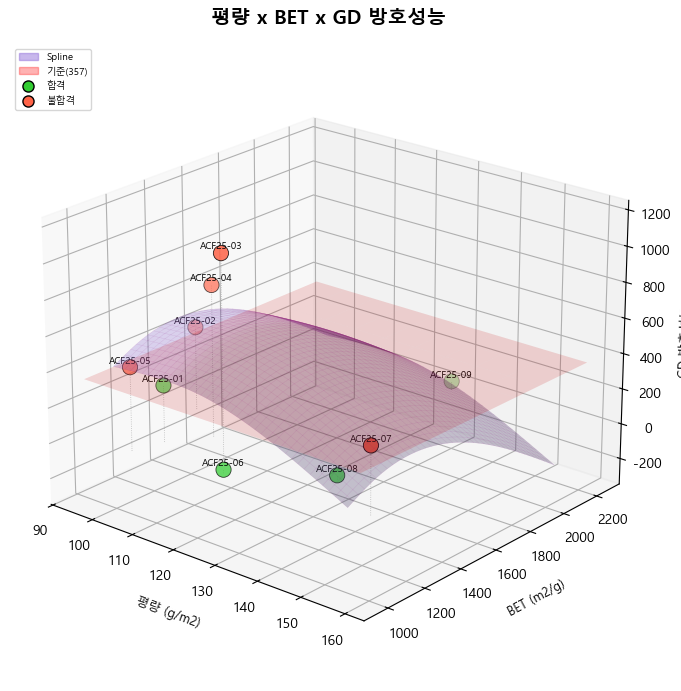

In [324]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.patches as mpatches

from matplotlib.lines import Line2D
from patsy import dmatrix, build_design_matrices

fig = plt.figure(figsize=(16, 7))
y_col = 'SWATCH(GD) 24h(Con)'
lim = GD_base
title = 'GD 방호성능'

ax = fig.add_subplot(1, 1, 1, projection='3d')

# 원본 데이터
x1 = df['평량(g/m2)'].values
x2 = df['BET(m2/g)'].values
y1 = df[y_col].values

# ---------------------------
# 1. 선형 회귀면
# ---------------------------
b0, b1, b2 = result1.params
y_pred = pred1
r2 = result1.rsquared
print('Linear R^2 =', r2)

x1_grid = np.linspace(x1.min(), x1.max(), 40)
x2_grid = np.linspace(x2.min(), x2.max(), 40)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)

Zg = b0 + b1 * X1g + b2 * X2g

# ax.plot_surface(X1g, X2g, Zg, alpha=0.12, color='royalblue', edgecolor='none')
# ax.plot_wireframe(X1g, X2g, Zg, alpha=0.10, color='navy', linewidth=0.3)

# ---------------------------
# 2. 스플라인 회귀 적합
# ---------------------------
k1 = float(np.median(x1))
k2 = float(np.median(x2))

formula = (
    f"cr(평량, knots=[{k1}], lower_bound={x1.min()}, upper_bound={x1.max()})"
    f" + cr(BET, knots=[{k2}], lower_bound={x2.min()}, upper_bound={x2.max()})"
)

# 학습용 design matrix
train_dict = {'평량': x1, 'BET': x2}
X_spline = dmatrix(formula, train_dict, return_type='dataframe')

model_spline = sm.OLS(y1, X_spline).fit()
print('Spline R^2 =', model_spline.rsquared)

# ---------------------------
# 3. 스플라인 회귀면 예측
# ---------------------------
# 여기서는 반드시 grid 데이터를 넣어야 함
grid_dict = {'평량': X1g.ravel(), 'BET': X2g.ravel()}

# 학습 때의 design_info를 이용해 grid 변환
Xg_spline = build_design_matrices(
    [X_spline.design_info],
    grid_dict
)[0]

pred_grid = model_spline.predict(Xg_spline)
Zg_spl = np.asarray(pred_grid).reshape(X1g.shape)

ax.plot_surface(X1g, X2g, Zg_spl, alpha=0.28, color='mediumpurple', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg_spl, alpha=0.15, color='purple', linewidth=0.3)
# ---------------------------
# 4. 실제 점 표시
# ---------------------------
colors = ['limegreen' if v <= lim else 'tomato' for v in y1]
sizes = [120] * len(y1)

ax.scatter(
    x1, x2, y1,
    c=colors, s=sizes,
    edgecolors='black', linewidths=0.6, depthshade=True
)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min() - 5,  x1.max() + 5,  10),
    np.linspace(x2.min() - 50, x2.max() + 50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red', edgecolor='none')

# 바닥에 수직 투영선
for xi, yi, zi in zip(x1, x2, y1):
    ax.plot([xi, xi], [yi, yi], [0, zi],
            color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 레이블
for _, row in df.iterrows():
    ax.text(
        row['평량(g/m2)'],
        row['BET(m2/g)'],
        row[y_col] + 20,
        row['Sample'],
        fontsize=7,
        ha='center'
    )

# 축 라벨
ax.set_xlabel('평량 (g/m2)', fontsize=9, labelpad=8)
ax.set_ylabel('BET (m2/g)', fontsize=9, labelpad=8)
ax.set_zlabel(f'{title}\n(mg·min/m³)', fontsize=9, labelpad=8)


# 범례
leg = [
    mpatches.Patch(color='mediumpurple', alpha=0.5, label='Spline'),
    # mpatches.Patch(color='royalblue', alpha=0.3, label='선형회귀'),
    mpatches.Patch(color='red', alpha=0.3, label=f'기준({lim})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen',
           markersize=8, label='합격', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
           markersize=8, label='불합격', markeredgecolor='black'),
]
ax.legend(handles=leg, fontsize=7, loc='upper left')

ax.view_init(elev=22, azim=-50)

plt.suptitle('평량 x BET x GD 방호성능', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Linear R^2 = 0.45412210887584614
Spline R^2 = 0.4996383804531854


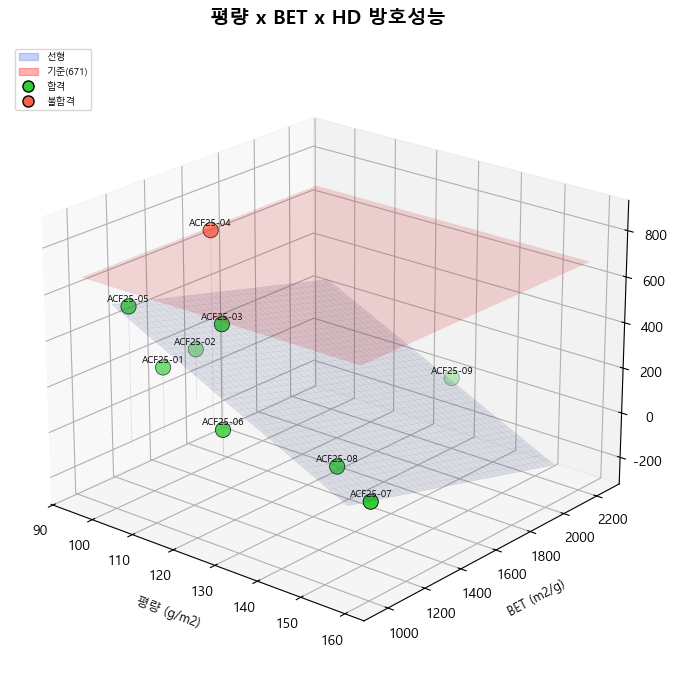

In [320]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.patches as mpatches

from matplotlib.lines import Line2D
from patsy import dmatrix, build_design_matrices

fig = plt.figure(figsize=(16, 7))
y_col = 'SWATCH(HD) 24h(Con)'
lim = HD_base
title = 'HD 방호성능'

ax = fig.add_subplot(1, 1, 1, projection='3d')

# 원본 데이터
x1 = df['평량(g/m2)'].values
x2 = df['BET(m2/g)'].values
y1 = df[y_col].values

# ---------------------------
# 1. 선형 회귀면
# ---------------------------
b0, b1, b2 = result2.params
y_pred = pred2
r2 = result2.rsquared
print('Linear R^2 =', r2)

x1_grid = np.linspace(x1.min(), x1.max(), 40)
x2_grid = np.linspace(x2.min(), x2.max(), 40)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)

Zg = b0 + b1 * X1g + b2 * X2g

ax.plot_surface(X1g, X2g, Zg, alpha=0.12, color='royalblue', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg, alpha=0.10, color='navy', linewidth=0.3)

# ---------------------------
# 2. 스플라인 회귀 적합
# ---------------------------
k1 = float(np.median(x1))
k2 = float(np.median(x2))

formula = (
    f"cr(평량, knots=[{k1}], lower_bound={x1.min()}, upper_bound={x1.max()})"
    f" + cr(BET, knots=[{k2}], lower_bound={x2.min()}, upper_bound={x2.max()})"
)

# 학습용 design matrix
train_dict = {'평량': x1, 'BET': x2}
X_spline = dmatrix(formula, train_dict, return_type='dataframe')

model_spline = sm.OLS(y1, X_spline).fit()
print('Spline R^2 =', model_spline.rsquared)

# ---------------------------
# 3. 스플라인 회귀면 예측
# ---------------------------
# 여기서는 반드시 grid 데이터를 넣어야 함
grid_dict = {'평량': X1g.ravel(), 'BET': X2g.ravel()}

# 학습 때의 design_info를 이용해 grid 변환
Xg_spline = build_design_matrices(
    [X_spline.design_info],
    grid_dict
)[0]

pred_grid = model_spline.predict(Xg_spline)
Zg_spl = np.asarray(pred_grid).reshape(X1g.shape)

# ax.plot_surface(X1g, X2g, Zg_spl, alpha=0.28, color='mediumpurple', edgecolor='none')
# ax.plot_wireframe(X1g, X2g, Zg_spl, alpha=0.15, color='purple', linewidth=0.3)
# ---------------------------
# 4. 실제 점 표시
# ---------------------------
colors = ['limegreen' if v <= lim else 'tomato' for v in y1]
sizes = [120] * len(y1)

ax.scatter(
    x1, x2, y1,
    c=colors, s=sizes,
    edgecolors='black', linewidths=0.6, depthshade=True
)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min() - 5,  x1.max() + 5,  10),
    np.linspace(x2.min() - 50, x2.max() + 50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red', edgecolor='none')

# 바닥에 수직 투영선
for xi, yi, zi in zip(x1, x2, y1):
    ax.plot([xi, xi], [yi, yi], [0, zi],
            color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 레이블
for _, row in df.iterrows():
    ax.text(
        row['평량(g/m2)'],
        row['BET(m2/g)'],
        row[y_col] + 20,
        row['Sample'],
        fontsize=7,
        ha='center'
    )

# 축 라벨
ax.set_xlabel('평량 (g/m2)', fontsize=9, labelpad=8)
ax.set_ylabel('BET (m2/g)', fontsize=9, labelpad=8)
ax.set_zlabel(f'{title}\n(mg·min/m³)', fontsize=9, labelpad=8)


# 범례
leg = [
    # mpatches.Patch(color='mediumpurple', alpha=0.5, label='Spline'),
    mpatches.Patch(color='royalblue', alpha=0.3, label='선형'),
    mpatches.Patch(color='red', alpha=0.3, label=f'기준({lim})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen',
           markersize=8, label='합격', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
           markersize=8, label='불합격', markeredgecolor='black'),
]
ax.legend(handles=leg, fontsize=7, loc='upper left')

ax.view_init(elev=22, azim=-50)

plt.suptitle('평량 x BET x HD 방호성능', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Linear R^2 = 0.45412210887584614
Spline R^2 = 0.4996383804531854


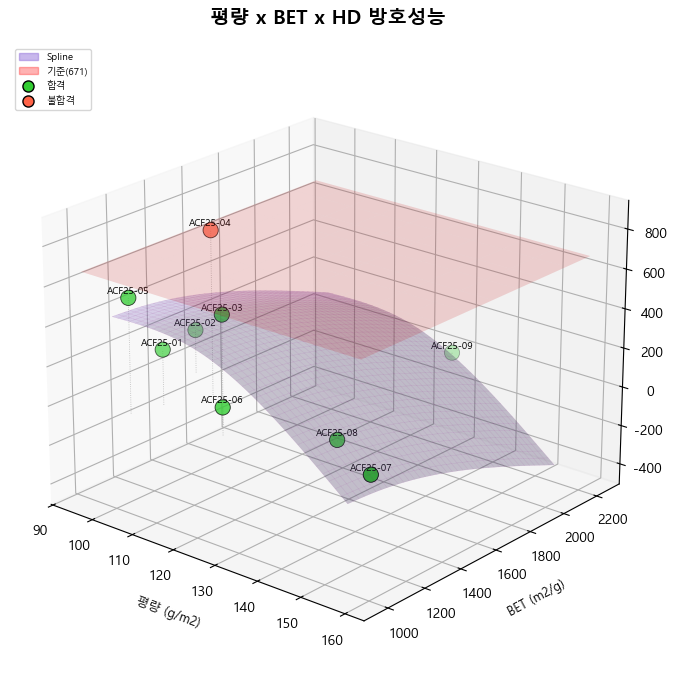

In [321]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.patches as mpatches

from matplotlib.lines import Line2D
from patsy import dmatrix, build_design_matrices

fig = plt.figure(figsize=(16, 7))
y_col = 'SWATCH(HD) 24h(Con)'
lim = HD_base
title = 'HD 방호성능'

ax = fig.add_subplot(1, 1, 1, projection='3d')

# 원본 데이터
x1 = df['평량(g/m2)'].values
x2 = df['BET(m2/g)'].values
y1 = df[y_col].values

# ---------------------------
# 1. 선형 회귀면
# ---------------------------
b0, b1, b2 = result2.params
y_pred = pred2
r2 = result2.rsquared
print('Linear R^2 =', r2)

x1_grid = np.linspace(x1.min(), x1.max(), 40)
x2_grid = np.linspace(x2.min(), x2.max(), 40)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)

Zg = b0 + b1 * X1g + b2 * X2g

# ax.plot_surface(X1g, X2g, Zg, alpha=0.12, color='royalblue', edgecolor='none')
# ax.plot_wireframe(X1g, X2g, Zg, alpha=0.10, color='navy', linewidth=0.3)

# ---------------------------
# 2. 스플라인 회귀 적합
# ---------------------------
k1 = float(np.median(x1))
k2 = float(np.median(x2))

formula = (
    f"cr(평량, knots=[{k1}], lower_bound={x1.min()}, upper_bound={x1.max()})"
    f" + cr(BET, knots=[{k2}], lower_bound={x2.min()}, upper_bound={x2.max()})"
)

# 학습용 design matrix
train_dict = {'평량': x1, 'BET': x2}
X_spline = dmatrix(formula, train_dict, return_type='dataframe')

model_spline = sm.OLS(y1, X_spline).fit()
print('Spline R^2 =', model_spline.rsquared)

# ---------------------------
# 3. 스플라인 회귀면 예측
# ---------------------------
# 여기서는 반드시 grid 데이터를 넣어야 함
grid_dict = {'평량': X1g.ravel(), 'BET': X2g.ravel()}

# 학습 때의 design_info를 이용해 grid 변환
Xg_spline = build_design_matrices(
    [X_spline.design_info],
    grid_dict
)[0]

pred_grid = model_spline.predict(Xg_spline)
Zg_spl = np.asarray(pred_grid).reshape(X1g.shape)

ax.plot_surface(X1g, X2g, Zg_spl, alpha=0.28, color='mediumpurple', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg_spl, alpha=0.15, color='purple', linewidth=0.3)
# ---------------------------
# 4. 실제 점 표시
# ---------------------------
colors = ['limegreen' if v <= lim else 'tomato' for v in y1]
sizes = [120] * len(y1)

ax.scatter(
    x1, x2, y1,
    c=colors, s=sizes,
    edgecolors='black', linewidths=0.6, depthshade=True
)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min() - 5,  x1.max() + 5,  10),
    np.linspace(x2.min() - 50, x2.max() + 50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red', edgecolor='none')

# 바닥에 수직 투영선
for xi, yi, zi in zip(x1, x2, y1):
    ax.plot([xi, xi], [yi, yi], [0, zi],
            color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 레이블
for _, row in df.iterrows():
    ax.text(
        row['평량(g/m2)'],
        row['BET(m2/g)'],
        row[y_col] + 20,
        row['Sample'],
        fontsize=7,
        ha='center'
    )

# 축 라벨
ax.set_xlabel('평량 (g/m2)', fontsize=9, labelpad=8)
ax.set_ylabel('BET (m2/g)', fontsize=9, labelpad=8)
ax.set_zlabel(f'{title}\n(mg·min/m³)', fontsize=9, labelpad=8)


# 범례
leg = [
    mpatches.Patch(color='mediumpurple', alpha=0.5, label='Spline'),
    # mpatches.Patch(color='royalblue', alpha=0.3, label='선형'),
    mpatches.Patch(color='red', alpha=0.3, label=f'기준({lim})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen',
           markersize=8, label='합격', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
           markersize=8, label='불합격', markeredgecolor='black'),
]
ax.legend(handles=leg, fontsize=7, loc='upper left')

ax.view_init(elev=22, azim=-50)

plt.suptitle('평량 x BET x HD 방호성능', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()